# 04. Streamlit 결함 검사 대시보드 — ViT + YOLOv8 통합

## 최종 산출물 (Final Deliverable)

이 노트북은 Track B-2의 **최종 산출물**인 제조 결함 검사 대시보드를 구축합니다.

| 노트북 | 내용 | 역할 |
|--------|------|----- |
| nb01 | ViT 개념 소개 | 이론 기반 |
| nb02 | ViT Transfer Learning | **분류 모델** 훈련 |
| nb03 | YOLOv8 Fine-tuning | **탐지 모델** 훈련 |
| **nb04** | **Streamlit 대시보드** | **✅ 통합 배포** |

### 대시보드 핵심 기능
1. **이미지 업로드** — 제조 라인에서 촬영한 제품 이미지 업로드
2. **ViT 결함 분류** — `정상 / 스크래치 / 패임 / 오염` 분류 + 신뢰도
3. **YOLOv8 결함 탐지** — 바운딩 박스 표시 + 위치 정보
4. **결과 통합 표시** — 분류 결과와 탐지 결과를 나란히 시각화

> **Note**: Streamlit 앱은 주피터 내부에서 직접 실행할 수 없습니다.  
> 이 노트북은 `src/app.py` 파일을 생성한 후,  
> 터미널에서 `streamlit run src/app.py` 명령으로 실행합니다.

In [1]:
# Cell 1: 기본 라이브러리 임포트 확인
import os
import sys
from pathlib import Path
import textwrap

print(f"Python version: {sys.version}")
print(f"Working directory: {Path.cwd()}")
print(f"Notebook directory: {Path('__file__').parent if '__file__' in dir() else 'notebooks/'}")

# src 디렉토리 경로 설정 (notebooks/ 기준 ../src/)
NOTEBOOK_DIR = Path.cwd()
# notebooks/ 디렉토리에서 실행 시 부모 디렉토리가 프로젝트 루트
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
SRC_DIR = PROJECT_ROOT / 'src'

print(f"\n프로젝트 루트: {PROJECT_ROOT}")
print(f"src 디렉토리: {SRC_DIR}")
print("\n✅ 기본 임포트 완료")

Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]
Working directory: /Users/hongmartin/dev/pug.marp.pptx/test_koreatechedu/workspace/github-repos/track-b2-vit-yolov8/notebooks
Notebook directory: notebooks/

프로젝트 루트: /Users/hongmartin/dev/pug.marp.pptx/test_koreatechedu/workspace/github-repos/track-b2-vit-yolov8
src 디렉토리: /Users/hongmartin/dev/pug.marp.pptx/test_koreatechedu/workspace/github-repos/track-b2-vit-yolov8/src

✅ 기본 임포트 완료


## 대시보드 아키텍처

```
┌─────────────────────────────────────────────────────────┐
│              제조 결함 검사 대시보드                       │
│                  (Streamlit App)                        │
├─────────────────────────────────────────────────────────┤
│  [사이드바]              [메인 영역]                       │
│  ┌──────────┐           ┌──────────────────────────┐    │
│  │ 모델 설정 │           │  이미지 업로드 영역        │    │
│  │ ViT 경로 │           │  ┌────────────────────┐  │    │
│  │ YOLO경로 │           │  │  드래그 & 드롭      │  │    │
│  │ 신뢰도임계│           │  └────────────────────┘  │    │
│  └──────────┘           └──────────────────────────┘    │
│                          ↓ 분석 실행                     │
│                         ┌──────────────────────────┐    │
│                         │ [ViT 결과] [YOLOv8 결과]  │    │
│                         │  분류: 스크래치 (92%)     │    │
│                         │  탐지: 3개 결함 발견      │    │
│                         └──────────────────────────┘    │
└─────────────────────────────────────────────────────────┘
```

### 기술 스택
- **Frontend**: Streamlit >= 1.28
- **분류 모델**: Hugging Face Transformers (ViT)
- **탐지 모델**: Ultralytics YOLOv8
- **이미지 처리**: PIL / OpenCV
- **시각화**: Streamlit native + matplotlib

In [2]:
# Cell 3: app.py 코드 작성 후 파일로 저장

APP_CODE = '''
"""
제조 결함 검사 대시보드
Track B-2: ViT + YOLOv8 통합 Streamlit 앱

실행 방법:
    streamlit run src/app.py
"""

import streamlit as st
import torch
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import io
import time
from pathlib import Path

# ── 페이지 설정 ────────────────────────────────────────────────
st.set_page_config(
    page_title="제조 결함 검사 시스템",
    page_icon="🔍",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ── 상수 정의 ──────────────────────────────────────────────────
DEFECT_CLASSES = ["정상 (Normal)", "스크래치 (Scratch)", "패임 (Dent)", "오염 (Contamination)"]
CLASS_COLORS = {"정상 (Normal)": "#2ecc71", "스크래치 (Scratch)": "#e74c3c",
                "패임 (Dent)": "#e67e22", "오염 (Contamination)": "#9b59b6"}


# ── 모델 로딩 (캐시) ───────────────────────────────────────────
@st.cache_resource
def load_vit_model(model_path: str):
    """ViT 분류 모델 로드 (Hugging Face Transformers)"""
    from transformers import ViTForImageClassification, ViTImageProcessor
    try:
        if Path(model_path).exists():
            processor = ViTImageProcessor.from_pretrained(model_path)
            model = ViTForImageClassification.from_pretrained(model_path)
        else:
            # 폴백: 사전 훈련 모델 (데모용)
            st.warning(f"모델 경로 없음: {model_path} → 데모 모드로 실행")
            processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
            model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")
        model.eval()
        return processor, model
    except Exception as e:
        st.error(f"ViT 모델 로드 실패: {e}")
        return None, None


@st.cache_resource
def load_yolo_model(model_path: str):
    """YOLOv8 탐지 모델 로드"""
    from ultralytics import YOLO
    try:
        if Path(model_path).exists():
            model = YOLO(model_path)
        else:
            st.warning(f"YOLOv8 경로 없음: {model_path} → 기본 모델(yolov8n)로 실행")
            model = YOLO("yolov8n.pt")
        return model
    except Exception as e:
        st.error(f"YOLOv8 모델 로드 실패: {e}")
        return None


# ── 추론 함수 ──────────────────────────────────────────────────
def run_vit_inference(image: Image.Image, processor, model) -> dict:
    """ViT 분류 추론"""
    if processor is None or model is None:
        return {"class": "오류", "confidence": 0.0, "all_scores": {}}

    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)[0]

    # nb02에서 훈련한 커스텀 모델의 경우 레이블 매핑
    if len(DEFECT_CLASSES) <= logits.shape[-1]:
        top_idx = probs[:len(DEFECT_CLASSES)].argmax().item()
        confidence = probs[top_idx].item()
        pred_class = DEFECT_CLASSES[top_idx]
        all_scores = {cls: probs[i].item() for i, cls in enumerate(DEFECT_CLASSES)
                      if i < len(probs)}
    else:
        top_idx = probs.argmax().item()
        confidence = probs[top_idx].item()
        pred_class = DEFECT_CLASSES[top_idx % len(DEFECT_CLASSES)]
        all_scores = {cls: float(probs[i % len(probs)]) for i, cls in enumerate(DEFECT_CLASSES)}

    return {"class": pred_class, "confidence": confidence, "all_scores": all_scores}


def run_yolo_inference(image: Image.Image, model, conf_threshold: float = 0.25) -> dict:
    """YOLOv8 탐지 추론 + 바운딩 박스 이미지 반환"""
    if model is None:
        return {"detections": [], "annotated_image": image, "count": 0}

    results = model(image, conf=conf_threshold, verbose=False)
    result = results[0]

    detections = []
    if result.boxes is not None:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf = box.conf[0].item()
            cls_id = int(box.cls[0].item())
            detections.append({
                "bbox": [x1, y1, x2, y2],
                "confidence": conf,
                "class_id": cls_id,
            })

    # 어노테이션 이미지
    annotated_array = result.plot()
    annotated_image = Image.fromarray(annotated_array[..., ::-1])  # BGR→RGB

    return {"detections": detections, "annotated_image": annotated_image, "count": len(detections)}


# ── UI 컴포넌트 ────────────────────────────────────────────────
def render_vit_results(vit_result: dict):
    """ViT 분류 결과 렌더링"""
    pred_class = vit_result["class"]
    confidence = vit_result["confidence"]
    color = CLASS_COLORS.get(pred_class, "#95a5a6")

    st.markdown(f"""
    <div style="background:{color}22; border-left:4px solid {color};
                padding:12px; border-radius:4px; margin:8px 0;">
        <h3 style="color:{color}; margin:0;">🏷️ {pred_class}</h3>
        <p style="margin:4px 0;">신뢰도: <strong>{confidence:.1%}</strong></p>
    </div>
    """, unsafe_allow_html=True)

    st.markdown("**클래스별 확률:**")
    for cls, score in vit_result.get("all_scores", {}).items():
        st.progress(score, text=f"{cls}: {score:.1%}")


def render_yolo_results(yolo_result: dict):
    """YOLOv8 탐지 결과 렌더링"""
    count = yolo_result["count"]
    status_color = "#e74c3c" if count > 0 else "#2ecc71"
    status_text = f"⚠️ {count}개 결함 탐지" if count > 0 else "✅ 결함 없음"

    st.markdown(f"""
    <div style="background:{status_color}22; border-left:4px solid {status_color};
                padding:12px; border-radius:4px; margin:8px 0;">
        <h3 style="color:{status_color}; margin:0;">{status_text}</h3>
    </div>
    """, unsafe_allow_html=True)

    st.image(yolo_result["annotated_image"], caption="YOLOv8 탐지 결과", use_container_width=True)

    if yolo_result["detections"]:
        st.markdown("**탐지된 결함 목록:**")
        for i, det in enumerate(yolo_result["detections"]):
            x1, y1, x2, y2 = [int(v) for v in det["bbox"]]
            st.write(f"  {i+1}. 위치: ({x1},{y1})→({x2},{y2}) | 신뢰도: {det['confidence']:.1%}")


# ── 메인 앱 ───────────────────────────────────────────────────
def main():
    # 헤더
    st.title("🔍 제조 결함 검사 대시보드")
    st.markdown("**Track B-2: ViT 분류 + YOLOv8 탐지 통합 시스템**")
    st.divider()

    # ── 사이드바 설정 ────────────────────────────────────────
    with st.sidebar:
        st.header("⚙️ 모델 설정")

        vit_model_path = st.text_input(
            "ViT 모델 경로",
            value="outputs/vit_defect_classifier",
            help="nb02에서 저장한 ViT 모델 디렉토리",
        )
        yolo_model_path = st.text_input(
            "YOLOv8 모델 경로",
            value="outputs/yolo_defect/weights/best.pt",
            help="nb03에서 훈련한 YOLOv8 가중치",
        )
        conf_threshold = st.slider(
            "YOLOv8 신뢰도 임계값", min_value=0.1, max_value=0.9, value=0.25, step=0.05
        )

        st.divider()
        st.markdown("### 시스템 정보")
        device = "GPU (CUDA)" if torch.cuda.is_available() else "CPU"
        st.info(f"디바이스: {device}")

        load_models_btn = st.button("🔄 모델 로드", type="primary", use_container_width=True)

    # ── 모델 로딩 ────────────────────────────────────────────
    if load_models_btn or "models_loaded" not in st.session_state:
        with st.spinner("모델 로딩 중..."):
            vit_processor, vit_model = load_vit_model(vit_model_path)
            yolo_model = load_yolo_model(yolo_model_path)
            st.session_state.vit_processor = vit_processor
            st.session_state.vit_model = vit_model
            st.session_state.yolo_model = yolo_model
            st.session_state.models_loaded = True

    # ── 이미지 업로드 ─────────────────────────────────────────
    st.subheader("📁 검사 이미지 업로드")
    uploaded_file = st.file_uploader(
        "제품 이미지를 업로드하세요 (JPG, PNG, BMP)",
        type=["jpg", "jpeg", "png", "bmp"],
        help="제조 라인에서 촬영한 제품 표면 이미지",
    )

    if uploaded_file is not None:
        image = Image.open(uploaded_file).convert("RGB")

        col_img, col_info = st.columns([2, 1])
        with col_img:
            st.image(image, caption=f"업로드: {uploaded_file.name}", use_container_width=True)
        with col_info:
            st.metric("이미지 크기", f"{image.width} × {image.height}")
            st.metric("파일 크기", f"{uploaded_file.size / 1024:.1f} KB")

        # ── 분석 실행 ────────────────────────────────────────
        if st.button("🚀 결함 검사 실행", type="primary", use_container_width=True):
            start_time = time.time()

            col_vit, col_yolo = st.columns(2)

            with col_vit:
                st.subheader("🧠 ViT 분류 결과")
                with st.spinner("ViT 추론 중..."):
                    vit_result = run_vit_inference(
                        image,
                        st.session_state.get("vit_processor"),
                        st.session_state.get("vit_model"),
                    )
                render_vit_results(vit_result)

            with col_yolo:
                st.subheader("📦 YOLOv8 탐지 결과")
                with st.spinner("YOLOv8 추론 중..."):
                    yolo_result = run_yolo_inference(
                        image,
                        st.session_state.get("yolo_model"),
                        conf_threshold,
                    )
                render_yolo_results(yolo_result)

            elapsed = time.time() - start_time
            st.success(f"✅ 분석 완료 ({elapsed:.2f}초)")

            # 검사 판정
            is_defective = (vit_result["class"] != "정상 (Normal)") or (yolo_result["count"] > 0)
            if is_defective:
                st.error("🚨 **판정: 불량 (FAIL)** — 제품을 제거하고 재검사하세요.")
            else:
                st.success("✅ **판정: 양호 (PASS)** — 제품이 품질 기준을 충족합니다.")
    else:
        st.info("👆 이미지를 업로드하면 자동으로 결함 검사를 시작합니다.")

        # 샘플 데모 표시
        st.markdown("---")
        st.markdown("### 📌 사용 안내")
        st.markdown("""
        1. **왼쪽 사이드바**에서 모델 경로를 설정하세요
            - ViT 모델: `nb02_vit_transfer_learning.ipynb` 에서 저장한 경로
            - YOLOv8 모델: `nb03_yolov8_finetuning.ipynb` 에서 저장한 경로
        2. **이미지 업로드** 영역에 제품 사진을 드래그하거나 클릭하여 업로드
        3. **결함 검사 실행** 버튼을 클릭하면 ViT + YOLOv8이 동시에 분석
        4. **판정 결과** (PASS/FAIL)를 확인하세요
        """)


if __name__ == "__main__":
    main()
'''

# src 디렉토리 생성
SRC_DIR.mkdir(parents=True, exist_ok=True)
APP_PATH = SRC_DIR / 'app.py'

# 파일 작성
APP_PATH.write_text(APP_CODE.strip(), encoding='utf-8')

print(f"✅ app.py 생성 완료: {APP_PATH}")
print(f"   파일 크기: {APP_PATH.stat().st_size:,} bytes")

✅ app.py 생성 완료: /Users/hongmartin/dev/pug.marp.pptx/test_koreatechedu/workspace/github-repos/track-b2-vit-yolov8/src/app.py
   파일 크기: 12,055 bytes


In [3]:
# Cell 4: 생성된 파일 확인
import os

APP_PATH = SRC_DIR / 'app.py'

# 파일 존재 확인
assert APP_PATH.exists(), f"app.py 파일이 생성되지 않았습니다: {APP_PATH}"
print(f"✅ 파일 확인: {APP_PATH}")
print(f"   크기: {APP_PATH.stat().st_size:,} bytes")
print()

# 파일 앞부분 출력
content = APP_PATH.read_text(encoding='utf-8')
lines = content.split('\n')
print(f"총 {len(lines)}줄")
print("─" * 60)
print("첫 30줄 미리보기:")
print("─" * 60)
for i, line in enumerate(lines[:30], 1):
    print(f"{i:3d}: {line}")
print("─" * 60)
print(f"... (이하 {len(lines)-30}줄 생략)")

# 주요 함수 존재 확인
checks = [
    ('import streamlit', 'Streamlit import'),
    ('load_vit_model', 'ViT 모델 로딩 함수'),
    ('load_yolo_model', 'YOLOv8 모델 로딩 함수'),
    ('run_vit_inference', 'ViT 추론 함수'),
    ('run_yolo_inference', 'YOLOv8 추론 함수'),
    ('def main()', '메인 함수'),
    ('file_uploader', '파일 업로더'),
]
print("\n주요 구성요소 확인:")
for keyword, desc in checks:
    found = keyword in content
    status = '✅' if found else '❌'
    print(f"  {status} {desc}: {keyword!r}")

✅ 파일 확인: /Users/hongmartin/dev/pug.marp.pptx/test_koreatechedu/workspace/github-repos/track-b2-vit-yolov8/src/app.py
   크기: 12,055 bytes

총 277줄
────────────────────────────────────────────────────────────
첫 30줄 미리보기:
────────────────────────────────────────────────────────────
  1: """
  2: 제조 결함 검사 대시보드
  3: Track B-2: ViT + YOLOv8 통합 Streamlit 앱
  4: 
  5: 실행 방법:
  6:     streamlit run src/app.py
  7: """
  8: 
  9: import streamlit as st
 10: import torch
 11: import numpy as np
 12: from PIL import Image, ImageDraw, ImageFont
 13: import io
 14: import time
 15: from pathlib import Path
 16: 
 17: # ── 페이지 설정 ────────────────────────────────────────────────
 18: st.set_page_config(
 19:     page_title="제조 결함 검사 시스템",
 20:     page_icon="🔍",
 21:     layout="wide",
 22:     initial_sidebar_state="expanded",
 23: )
 24: 
 25: # ── 상수 정의 ──────────────────────────────────────────────────
 26: DEFECT_CLASSES = ["정상 (Normal)", "스크래치 (Scratch)", "패임 (Dent)", "오염 (Contamination)"]
 27: C

## 실행 방법

### 로컬 실행
```bash
# 1. 의존성 설치
pip install streamlit>=1.28.0 transformers torch ultralytics pillow

# 2. 프로젝트 루트에서 실행
cd /path/to/track-b2-vit-yolov8
streamlit run src/app.py

# 3. 브라우저에서 열기
# → http://localhost:8501
```

### 포트 변경
```bash
streamlit run src/app.py --server.port 8502
```

### 네트워크 공유 (강의실 시연용)
```bash
streamlit run src/app.py --server.address 0.0.0.0
# → http://<your-ip>:8501 으로 접속 가능
```

### Google Colab 실행
```python
# Colab에서 Streamlit 실행 (ngrok 터널 이용)
!pip install streamlit pyngrok -q
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print(f"대시보드 URL: {public_url}")
!streamlit run src/app.py &
```

### 모델 경로 설정
| 항목 | 기본값 | nb02/03 저장 경로 |
|------|--------|------------------|
| ViT 모델 | `outputs/vit_defect_classifier` | nb02의 `model.save_pretrained()` 경로 |
| YOLOv8 모델 | `outputs/yolo_defect/weights/best.pt` | nb03의 훈련 결과 경로 |

/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_92721/3374425272.py:91: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_92721/3374425272.py:91: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_92721/3374425272.py:91: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_92721/3374425272.py:91: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_92721/3374425272.py:91: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykern

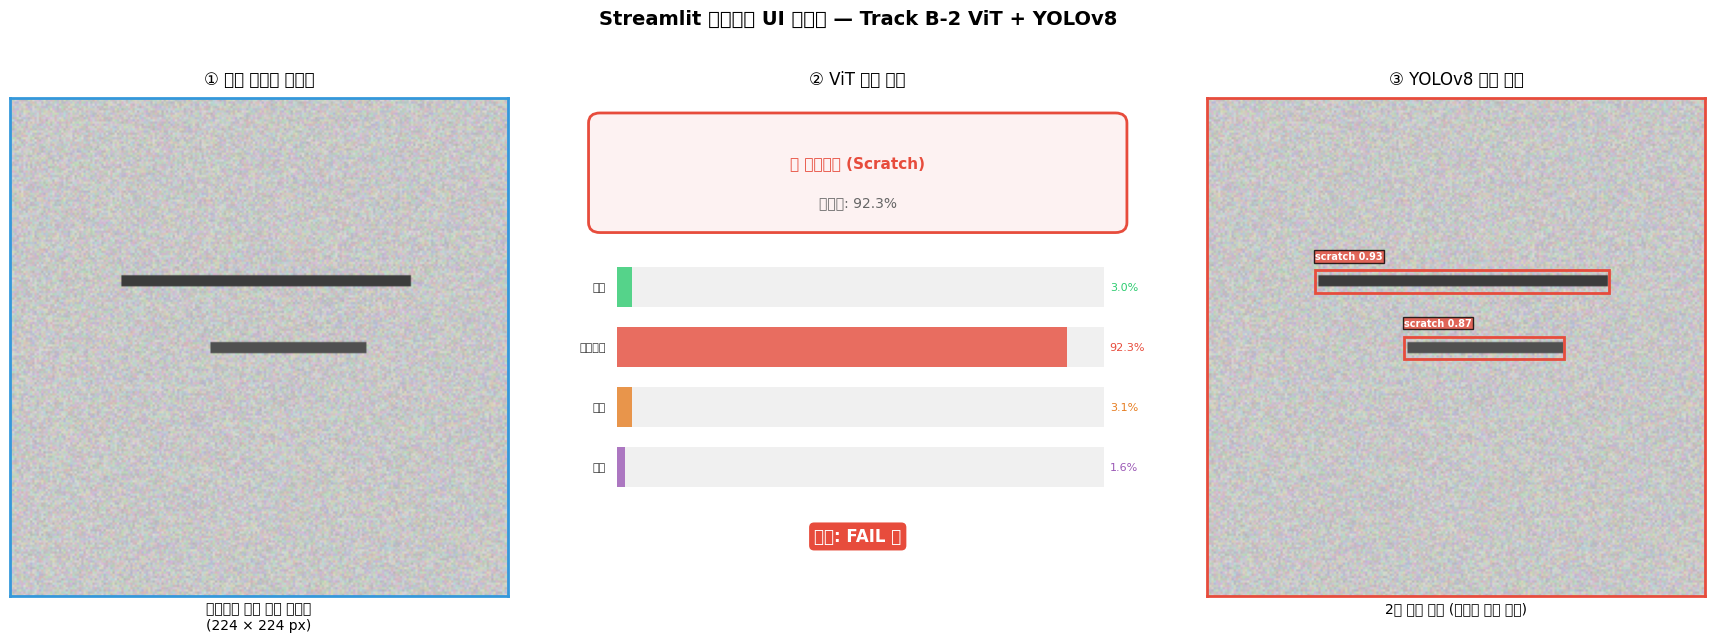

✅ 대시보드 UI 개념도 저장 완료


In [4]:
# Cell 6: 대시보드 UI 개념 시각화 (matplotlib)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Streamlit 대시보드 UI 개념도 — Track B-2 ViT + YOLOv8', 
             fontsize=14, fontweight='bold', y=1.02)

# ── 패널 1: 입력 이미지 ──────────────────────────────────────
ax1 = axes[0]
ax1.set_title('① 입력 이미지 업로드', fontsize=12, pad=10)

# 이미지 영역 모의
img_mock = np.random.randint(180, 220, (224, 224, 3), dtype=np.uint8)
# 스크래치 추가
img_mock[80:85, 50:180, :] = [60, 60, 60]
img_mock[110:115, 90:160, :] = [80, 80, 80]
ax1.imshow(img_mock)
ax1.set_xlabel('업로드된 제품 표면 이미지\n(224 × 224 px)', fontsize=10)
ax1.set_xticks([])
ax1.set_yticks([])
for spine in ax1.spines.values():
    spine.set_edgecolor('#3498db')
    spine.set_linewidth(2)

# ── 패널 2: ViT 분류 결과 ────────────────────────────────────
ax2 = axes[1]
ax2.set_title('② ViT 분류 결과', fontsize=12, pad=10)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')

# 결과 박스
result_box = FancyBboxPatch((0.05, 0.75), 0.9, 0.2,
                             boxstyle="round,pad=0.02",
                             facecolor='#fdf2f2', edgecolor='#e74c3c', linewidth=2)
ax2.add_patch(result_box)
ax2.text(0.5, 0.87, '🏷️ 스크래치 (Scratch)', ha='center', va='center',
         fontsize=11, fontweight='bold', color='#e74c3c')
ax2.text(0.5, 0.79, '신뢰도: 92.3%', ha='center', va='center',
         fontsize=10, color='#666')

# 클래스별 확률 바
classes = ['정상', '스크래치', '패임', '오염']
probs = [0.03, 0.923, 0.031, 0.016]
colors = ['#2ecc71', '#e74c3c', '#e67e22', '#9b59b6']
y_positions = [0.62, 0.50, 0.38, 0.26]

for cls, prob, color, y in zip(classes, probs, colors, y_positions):
    # 바 배경
    ax2.barh(y, 0.85, left=0.08, height=0.08, color='#f0f0f0', zorder=1)
    # 확률 바
    ax2.barh(y, prob * 0.85, left=0.08, height=0.08, color=color, alpha=0.8, zorder=2)
    ax2.text(0.06, y, cls, ha='right', va='center', fontsize=8, color='#333')
    ax2.text(0.94, y, f'{prob:.1%}', ha='left', va='center', fontsize=8, color=color)

ax2.text(0.5, 0.12, '판정: FAIL ❌', ha='center', va='center',
         fontsize=12, fontweight='bold', color='white',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#e74c3c', edgecolor='none'))

# ── 패널 3: YOLOv8 탐지 결과 ─────────────────────────────────
ax3 = axes[2]
ax3.set_title('③ YOLOv8 탐지 결과', fontsize=12, pad=10)

# 탐지 결과 이미지
det_img = img_mock.copy()
ax3.imshow(det_img)

# 바운딩 박스
bbox_configs = [
    {'xy': (48, 77), 'width': 132, 'height': 10, 'label': 'scratch 0.93'},
    {'xy': (88, 107), 'width': 72, 'height': 10, 'label': 'scratch 0.87'},
]
for cfg in bbox_configs:
    rect = mpatches.Rectangle(cfg['xy'], cfg['width'], cfg['height'],
                               linewidth=2, edgecolor='#e74c3c', facecolor='none')
    ax3.add_patch(rect)
    ax3.text(cfg['xy'][0], cfg['xy'][1] - 5, cfg['label'],
             color='white', fontsize=7, fontweight='bold',
             bbox=dict(facecolor='#e74c3c', alpha=0.8, pad=1))

ax3.set_xlabel('2개 결함 탐지 (바운딩 박스 표시)', fontsize=10)
ax3.set_xticks([])
ax3.set_yticks([])
for spine in ax3.spines.values():
    spine.set_edgecolor('#e74c3c')
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig(SRC_DIR.parent / 'outputs' / 'dashboard_preview.png',
            dpi=120, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ 대시보드 UI 개념도 저장 완료")

## Track B-2 완료 요약

### 학습 성과

| 노트북 | 핵심 기술 | 학습 내용 |
|--------|----------|----------|
| nb01 | Vision Transformer (ViT) | 어텐션 메커니즘, 패치 임베딩 |
| nb02 | Transfer Learning | 사전 훈련 모델 파인튜닝, 결함 분류 |
| nb03 | YOLOv8 | 객체 탐지, YOLO 아키텍처, 바운딩 박스 |
| **nb04** | **Streamlit 배포** | **웹 앱 통합, 실시간 추론 대시보드** |

### 프로덕션 배포 고려사항

```
현재 (nb04)          →    프로덕션
────────────────────────────────────────────
로컬 Streamlit        →  Docker + Kubernetes
단일 이미지 처리       →  배치 처리 파이프라인
CPU 추론             →  GPU 서버 (NVIDIA T4+)
단순 파일 업로드       →  RTSP 카메라 스트림
수동 판정            →  자동 불량품 분류 시스템
```

### 다음 단계
- **X1 트랙**: RAG 기반 결함 분석 보고서 자동 생성
- **파일럿 설계**: 실제 제조 라인에 적용하는 PoC 설계서 작성